In [1]:
import torch
from equiv_dens.training.parse_command_line_arguments import parse_command_line_arguments
from equiv_dens.training.errors import ErrorDict
from equiv_dens.data.density_dataset import AtomsDensityData
from equiv_dens.data.hamiltonian_dataset import seeded_random_split
from equiv_dens.utils.grids import cubical_grid, cubical_sampling,\
    dftpy_grid, CubicalGrid, spherical_grid, spherical_radial_sampling
from equiv_dens.training.model_loader import load_model
import equiv_dens.utils.base as utils
from equiv_dens.utils import orbitals
from functools import partial
import os
import numpy as np

%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/pyscf/lib/misc.py:47: H5pyDeprecationWarning: Using default_file_mode other than 'r' is deprecated. Pass the mode to h5py.File() instead.
  h5py.get_config().default_file_mode = 'a'


In [2]:
args, hyperparam_args = parse_command_line_arguments(arg_file='C_dens.txt')

print('type dtype', type(args.dtype))
args.fix_arguments = True
print('args np dir', args.np_dataset)
# no restart directory specified
directory = args.restart  # load directory name
# load latest checkpoint
checkpoint_path = os.path.join(directory, 'checkpoints')  # checkpoint directory
checkpoint = torch.load(os.path.join(
    checkpoint_path, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['step']
model_code = checkpoint['ID']  # load ID
step = checkpoint['step']
for arg in vars(checkpoint['args']):
    if args.fix_arguments:
        if arg in hyperparam_args:
            print('loading hyperparam arg', arg)
            setattr(args, arg, getattr(checkpoint['args'], arg))
    else:
        print('loading all arg', arg)
        setattr(args, arg, getattr(checkpoint['args'], arg))
restore = True

args.best_model_path = 'best_' + model_code + '.pth'
print('best_model_path', args.best_model_path)

print('model code:', model_code)
# determine whether GPU is used for training
print('args use gpu', args.use_gpu)
args.use_gpu = False
# load dataset(s)
print("loading density from" + str(args.dens_dataset) + "...")
print("loading atoms from" + args.np_dataset + "...")

args.verbose = 0
args.use_gpu = False
args.cube_grid = True
args.radii_adjust = True 
args.expansion_constraint=None
if args.cube_grid:
    args.cube_origin = -0.25
    args.cube_extent = 0.5
    args.cube_size = 50
    args.radii_adjust = False
    grid_origin = args.cube_origin
    grid_extent = np.array([args.cube_extent] * 3)
    grid_fn = partial(cubical_grid, nx=args.cube_size, ny=args.cube_size, nz=args.cube_size,
                      extent=grid_extent,
                      origin=np.array([grid_origin] * 3))
    sampling_fn = cubical_sampling
else:
    grid_fn = partial(spherical_grid, level=2)
    sampling_fn = partial(spherical_radial_sampling, rotate=False)
    grid_origin = 0
    grid_extent = None

    
dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust)

dataset_df = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                           orbitals_path=args.orbitals_file,
                           density_n_samp=10000000000,
                           required_properties=['density'],
                           center_positions=False,
                           radial_coeffs_file=args.radial_coeffs_file,
                           dtype=torch.float32,
                           grid_fn=grid_fn,
                           sampling_fn=sampling_fn,
                           grid_extent=grid_extent,
                           grid_origin=grid_origin,
                           verbose=0,
                           radii_adjust=args.radii_adjust,
                           projected_density=True)
    
#dataset_df.density_fitting[0]['df_coeff'] *= 0
sample = dataset.get_properties([0])
sample_df = dataset_df.get_properties([0])
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)
print(dataset.atoms)
model = load_model(args, dataset)
result = model(sample)
print('ml density loss', torch.sum(torch.abs(sample['density'] - result['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('ml density integral', torch.sum(result['density'] * sample['coord_weights']))


type dtype <class 'torch.dtype'>
args np dir datasets/C_augccpvdz.npy
loading hyperparam arg activation
loading hyperparam arg order
loading hyperparam arg mixing_order
loading hyperparam arg order_en
loading hyperparam arg mixing_order_en
loading hyperparam arg num_features
loading hyperparam arg num_basis_functions
loading hyperparam arg num_radial_components
loading hyperparam arg num_energy_features
loading hyperparam arg num_modules
loading hyperparam arg num_residual_pre_x
loading hyperparam arg num_residual_post_x
loading hyperparam arg num_residual_pre_vi
loading hyperparam arg num_residual_pre_vj
loading hyperparam arg num_residual_post_v
loading hyperparam arg num_residual_output
loading hyperparam arg num_energy_output
loading hyperparam arg basis_functions
loading hyperparam arg cutoff
loading hyperparam arg orthonormal_basis
loading hyperparam arg expansion_constraint
loading hyperparam arg integral_constraint
loading hyperparam arg integral_scale
loading hyperparam arg in

In [4]:

print(dataset_df.density_fitting[0]['df_coeff'].shape)

(142,)


dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


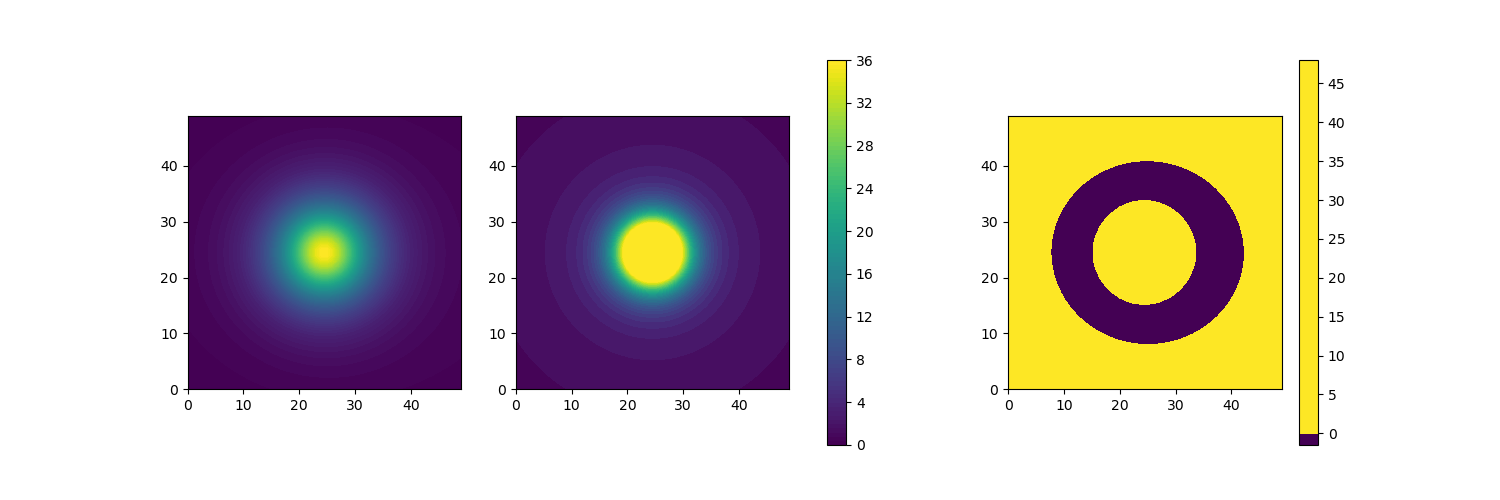

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
dens = np.array(sample['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = result['density'].cpu().data.squeeze().numpy()

p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c1, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

dens shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


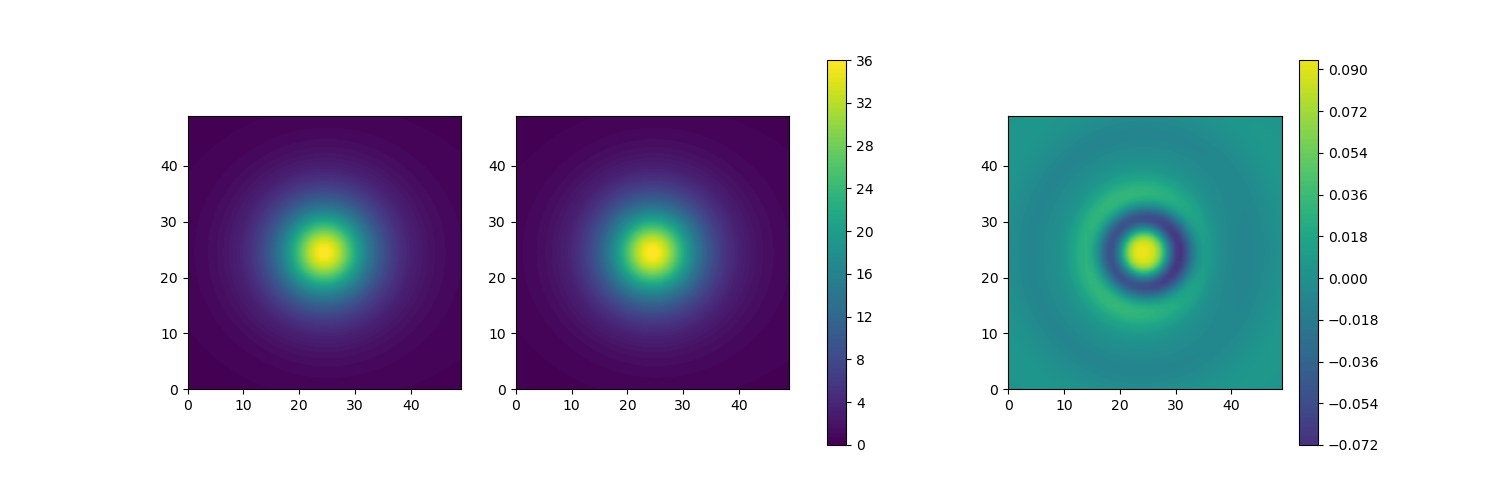

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
dens = np.array(sample['density'].squeeze())
print('dens shape', dens.shape)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = sample_df['density'].squeeze()

p_dens = p_dens[idx].reshape(50, 50)

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [5]:
dataset.mols[0].atom_coords()

array([[0., 0., 0.]])

In [5]:
dataset_df.density_fitting[0]['df_coeff']

print(dataset_df.density_fitting[0]['df_coeff'].shape)

(142,)


In [6]:
ml_coeffs = orbitals.coeffs_dict_to_vector(result, model.density_repr_model[0].orbital_basis, result['atom_numbers'], radial_coeffs=False)
print(ml_coeffs)

print(dataset_df.density_fitting[0]['df_coeff'].shape)

{'spherical_coeffs': tensor([[0.3405, 0.1820, 0.6742, 0.6707, 0.6481, 0.1162, 1.3290, 0.1317, 0.3803,
         0.2165, 0.0393, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
       

In [7]:
dataset_df.density_fitting[0]['df_coeff'] = ml_coeffs['spherical_coeffs'].detach().cpu()
sample = dataset.get_properties(0)
sample_df = dataset_df.get_properties(0)
print('density loss', torch.sum(torch.abs(sample['density'] - sample_df['density']) * sample['coord_weights'])/sample['atom_numbers'])
print('density integral', torch.sum(sample['density'] * sample['coord_weights']))
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(dataset_df.density_fitting)

print(dataset_df.density_fitting[0]['df_coeff'].shape)

ao [[[4.63571408e-310 4.63571276e-310 0.00000000e+000 ... 5.08834818e-315
   1.42144121e-091 1.88371686e-037]
  [6.56034515e-003 3.03668384e-005 5.37799945e-013 ... 2.73040280e-008
   2.35531277e-009 1.15176779e-009]
  [9.26576289e-008 5.08783562e-315 7.07328882e-103 ... 2.08215027e-001
   3.05465726e-005 7.17323876e-013]
  ...
  [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 0.00000000e+000
   0.00000000e+000 0.00000000e+000]
  [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 0.00000000e+000
   0.00000000e+000 0.00000000e+000]
  [0.00000000e+000 0.00000000e+000 0.00000000e+000 ... 0.00000000e+000
   0.00000000e+000 0.00000000e+000]]]
ao_loc [ 0  2  3  4  7 10 13 18 23]
atm [[ 6 20  1 23  0  0]]
bas [[ 0  0  8  2  0 24 32  0]
 [ 0  0  1  1  0 48 49  0]
 [ 0  0  1  1  0 50 51  0]
 [ 0  1  3  1  0 52 55  0]
 [ 0  1  1  1  0 58 59  0]
 [ 0  1  1  1  0 60 61  0]
 [ 0  2  1  1  0 62 63  0]
 [ 0  2  1  1  0 64 65  0]]
env [ 1.37036000e+02  0.00000000e+00  0.00000000e+00  0.00000000

In [9]:
print(result['radial_width'])
print(result['radial_scale'])

[{(6, 0): tensor([[[[-0.5527,  0.8194, -0.1507, -0.8931,  0.9270, -0.9948,  0.0251,
           -0.9928, -0.9919,  0.9459,  0.9361]]]], grad_fn=<CopySlices>), (6, 1): tensor([[[[-0.0145,  0.9270, -0.4739, -0.5478,  0.5423, -0.3750,  0.2172,
            0.6166]]]], grad_fn=<CopySlices>), (6, 2): tensor([[[[ 0.6114, -0.6768,  0.0172,  0.3358,  0.2783, -0.1420]]]],
       grad_fn=<CopySlices>), (6, 3): tensor([[[[-0.3429,  0.8505, -0.4086, -0.7597]]]], grad_fn=<CopySlices>), (6, 4): tensor([[[[ 0.0051,  0.1783, -0.7991]]]], grad_fn=<CopySlices>), (6, 5): tensor([[[[-0.8729, -0.1194]]]], grad_fn=<CopySlices>)}]
[{(6, 0): tensor([[[[1.7047, 0.1548, 0.3447, 0.4578, 0.1779, 0.3977, 0.3864, 0.0984,
           0.3151, 0.2524, 0.4633]]]], grad_fn=<CopySlices>), (6, 1): tensor([[[[0.6520, 0.5972, 0.9101, 0.7835, 0.6741, 0.8985, 0.9916, 0.6546]]]],
       grad_fn=<CopySlices>), (6, 2): tensor([[[[1.3544, 1.1048, 0.5409, 0.6044, 0.9909, 0.3176]]]],
       grad_fn=<CopySlices>), (6, 3): tensor([[[[0.

In [10]:
109.4367/5.4809

19.966921490996004

In [11]:
dataset_df.density_fitting[0]['df_coeff'] *= 0
print(dataset_df.density_fitting[0]['df_coeff'].shape)
dataset_df.density_fitting[0]['df_coeff'][:, 11] = 1
print(dataset_df.density_fitting[0]['df_coeff'])

sample_df = dataset_df.get_properties(0)
df_integral =  torch.sum(sample_df['density'] * sample['coord_weights'])
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))
print(torch.max(sample_df['density']))

torch.Size([1, 142])
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
df integral tensor(-3.3760e-09)
tensor(19.3701)


In [12]:
dataset_df.density_fitting[0]['df_coeff'] *= 0
print(dataset_df.density_fitting[0]['df_coeff'].shape)
dataset_df.density_fitting[0]['df_coeff'][:, 13] = 1

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': -1 * dataset_df.density_fitting[0]['df_coeff']}, model.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:result['radial_width'][i][key]*0 for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:result['radial_scale'][i][key]*0 for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
#sample['radial_scale'] = result['radial_scale']
print('radial width', sample['radial_width'])
res = model.property_models['density'](sample)

ml_integral = torch.sum(res['density'] * sample['coord_weights'])
print('ml integral', torch.sum(res['density'] * sample['coord_weights']))
ratio = ml_integral/df_integral
print('ratio', ratio)
print(torch.max(res['density']))

torch.Size([1, 142])
radial width [{(6, 0): tensor([[[[-0., 0., -0., -0., 0., -0., 0., -0., -0., 0., 0.]]]],
       grad_fn=<MulBackward0>), (6, 1): tensor([[[[-0., 0., -0., -0., 0., -0., 0., 0.]]]], grad_fn=<MulBackward0>), (6, 2): tensor([[[[0., -0., 0., 0., 0., -0.]]]], grad_fn=<MulBackward0>), (6, 3): tensor([[[[-0., 0., -0., -0.]]]], grad_fn=<MulBackward0>), (6, 4): tensor([[[[0., 0., -0.]]]], grad_fn=<MulBackward0>), (6, 5): tensor([[[[-0., -0.]]]], grad_fn=<MulBackward0>)}]
density expansion time: 0.06025123596191406
ml integral tensor(-1.4872e-08, grad_fn=<SumBackward0>)
ratio tensor(4.4052, grad_fn=<DivBackward0>)
tensor(264.6841, grad_fn=<MaxBackward1>)


In [13]:
print(np.sqrt(1/(4*np.pi)))

0.28209479177387814


idx [    23   2523   5023 ... 119973 122473 124973]
coords space shape torch.Size([1, 125000, 3])
torch.Size([1, 125000])


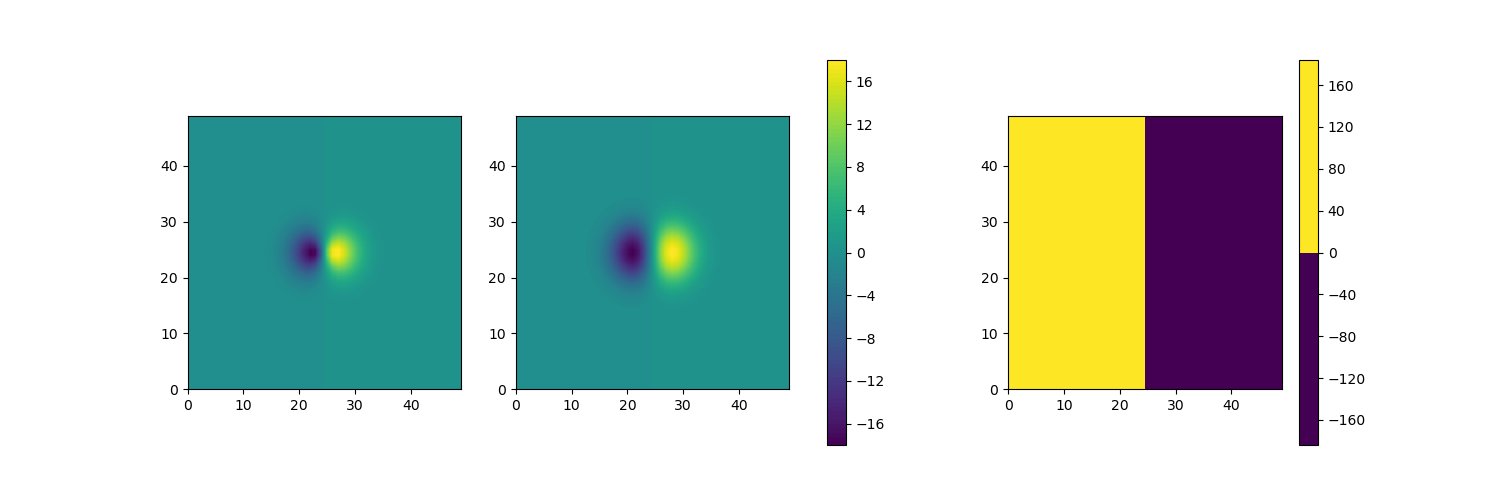

In [14]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
x, y  = np.meshgrid(np.arange(50), np.arange(50))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 23
idx = np.ravel_multi_index((x_f, y_f, z_f), (50, 50, 50))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = res['density'].squeeze().detach().cpu().numpy()[idx]
dens2d = dens2d.reshape(50, 50)

indices = np.stack((x_f, y_f, z_f), axis=1)
coords_space = sample['coords']
print('coords space shape', coords_space.shape)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')
print(result['density'].shape)

p_dens = sample_df['density'].squeeze()

p_dens = p_dens[idx].reshape(50, 50)
vmin = np.min(p_dens.numpy())
vmax = np.max(p_dens.numpy())

ax2 = fig.add_subplot(132)
c2 = ax2.contourf(x, y, p_dens, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, p_dens-dens2d, vmin=-0.1, vmax=0.1, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
#plt.savefig('figures/target_vs_result.pdf', dpi=300)
plt.show()

In [15]:
dataset_df.density_fitting[0]['df_coeff'].shape

torch.Size([1, 142])

In [67]:
sample_idx = 0
bas_idx = 0
dataset_df.density_fitting[sample_idx]['df_coeff'] *= 0
print(dataset_df.density_fitting[sample_idx]['df_coeff'].shape)
dataset_df.density_fitting[sample_idx]['df_coeff'][:, bas_idx] = 1 
print(dataset_df.density_fitting[sample_idx]['df_coeff'])

sample_df = dataset_df.get_properties(sample_idx)
df_integral =  torch.sum(sample_df['density'] * sample['coord_weights'])
print('df integral', torch.sum(sample_df['density'] * sample['coord_weights']))

coeffs = orbitals.vector_to_coeffs_dict({'spherical_coeffs': dataset_df.density_fitting[sample_idx]['df_coeff']}, model.density_repr_model[0].orbital_basis,
                                         result['atom_numbers'], radial_coeffs=False)
sample['spherical_coeffs'] = coeffs['spherical_coeffs']
sample['radial_width'] = [{key:result['radial_width'][i][key]*sample_idx for key in result['radial_width'][i].keys()} for i in range(len(result['radial_width']))]
sample['radial_scale'] = [{key:result['radial_scale'][i][key]*sample_idx for key in result['radial_scale'][i].keys()} for i in range(len(result['radial_scale']))]
# sample['radial_scale'] = result['radial_scale']
# print('spherical coeffs', sample['spherical_coeffs'])
res = model.property_models['density'](sample)

mol = dataset_df.mols[sample_idx]
if not mol._built and mol.basis != dataset_df.density_fitting[sample_idx]['auxbasis']:
    mol.basis = self.density_fitting[sample_idx]['auxbasis']
    # build_start = time.time()
    mol.build()
ctr_coeff = mol._libcint_ctr_coeff(bas_idx)
print('contracted coeff', ctr_coeff)

ml_integral = torch.sum(res['density'] * sample['coord_weights']) * float(ctr_coeff) * utils.to_angstrom**2
print('ml integral', torch.sum(res['density'] * sample['coord_weights']))
ratio = ml_integral/df_integral
print('ratio', ratio)
print('sqrt ratio', torch.sqrt(ratio))
print(utils.to_bohr)


torch.Size([1, 142])
tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
ao [[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
ao_loc [  0   1   2   3   4   5   6   7   8   9  10  11  14  17  20  23  26  29
  32  35  40  45  50  55  60  65  72  79  86  93 102 111 120 131 142]
atm [[ 6 20  1 23  0